# FWI with external PML
The loaded model contains only the physical region (including air, if present). PML is added internally; coordinates and plots use the physical model. The optimizer updates only physical material tensors.


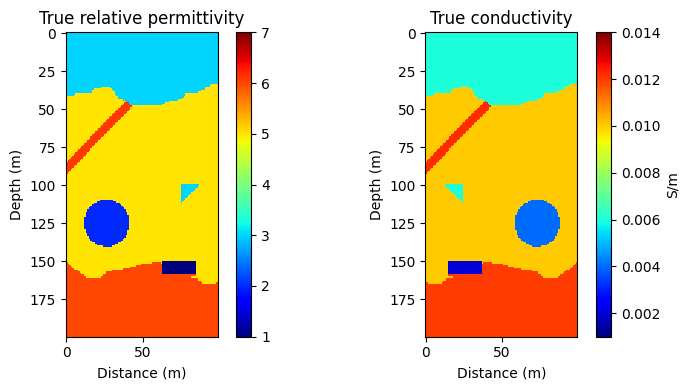

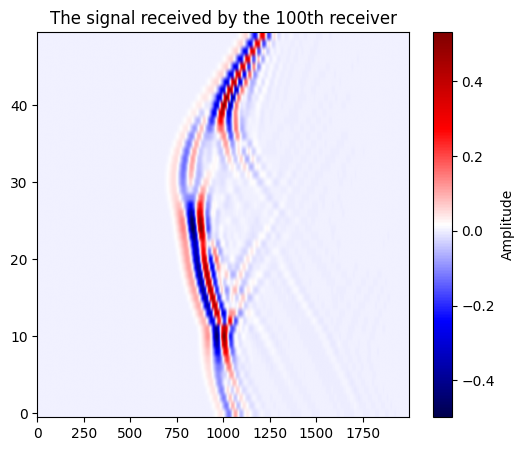

In [21]:
import torch
import numpy as np
import sys 
from pathlib import Path
src_path=Path.cwd().parent / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
import DeepGPR
import matplotlib.pyplot as plt
from skimage import filters
import time

# Set up the parameters and models
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dx=0.05
dt=5e-11
nt=2000

ert = torch.tensor(np.load('2DFWImodel.npy'))
nx, ny = ert.shape
shot_x = torch.arange(0, nx, 4, device=device)
nshots = shot_x.numel()

source_location=torch.zeros((nshots,1,3),device=device,dtype=torch.int)
source_location[:,0,0]=shot_x
source_location[:,:,1]=0

receiver_location=torch.zeros((nshots,nx,3),device=device,dtype=torch.int)
receiver_location[:,:,0]=torch.arange(nx, device=device).repeat(nshots,1)
# Last physical depth cell; acquisition coordinates exclude external PML.
receiver_location[:,:,1]=ny - 1


freq=2e8
peak_time = 1 / freq
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR.ricker(freq, nt, dt, peak_time).to(device)


set = ert.clone()*0.002
set[95:, :] = torch.flip(set[95:, :], dims=[1])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
im1 = axes[0].imshow(ert.cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=7,vmin=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('True relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(set.cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=0.014,vmin=0.001)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('True conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()


#Forward modeling
r_obs = DeepGPR.compute(
    device=device, dx=dx, dt=dt, 
    source_amplitudes=source_amplitudes,
    source_location=source_location, 
    receiver_location=receiver_location, 
    er=ert, se=set
)[-1]

plt.figure(figsize=(6, 5)) 
im = plt.imshow(r_obs[:,:,100].detach().cpu().numpy(), cmap='seismic', origin='lower',aspect='auto')
plt.colorbar(im, label='Amplitude') 
plt.title("The signal received by the 100th receiver") 
plt.show()


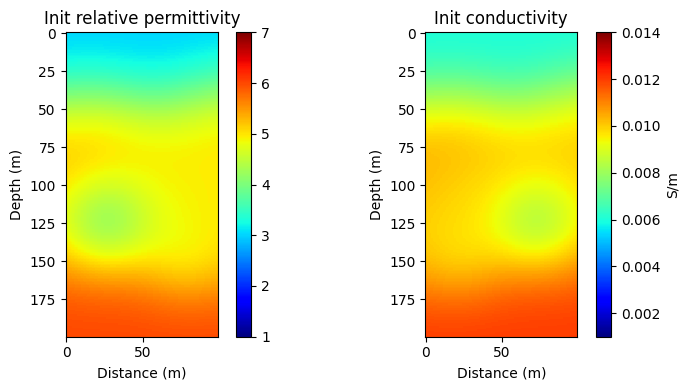

In [22]:
er=torch.tensor(filters.gaussian(ert,sigma=20),device=device)
se=torch.tensor(filters.gaussian(set,sigma=20),device=device)


optimiser_phase1 = torch.optim.Adam([
    {'params': er, 'lr': 0.2},
])

optimiser_phase2 = torch.optim.Adam([
    {'params': er, 'lr': 0.1},
    {'params': se, 'lr': 0.0001}
])
phase1_epochs = 50 
losses = []
n_epochs=301

loss_fnmse = torch.nn.MSELoss()
loss_fnl1= torch.nn.L1Loss()

start_time = time.time()


tv_criterion = DeepGPR.TVRegularization(weight_ep=20,weight_sigma=0.0000000001).to(device)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
im1 = axes[0].imshow(er.cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=7,vmin=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Init relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(se.cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=0.014,vmin=0.001)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Init conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()


/tmp/ipykernel_179349/2709531244.py:17: RuntimeWarning: model_gradient_sampling_interval > 1 uses a weighted temporal-sampling approximation; use interval 1 with float32 storage for exact gradients.
  r = DeepGPR.compute(


Epoch 0, Total Loss: 176460.84 (Data: 167663.09), Epoch Time: 0.65s, Total Time: 0.82s


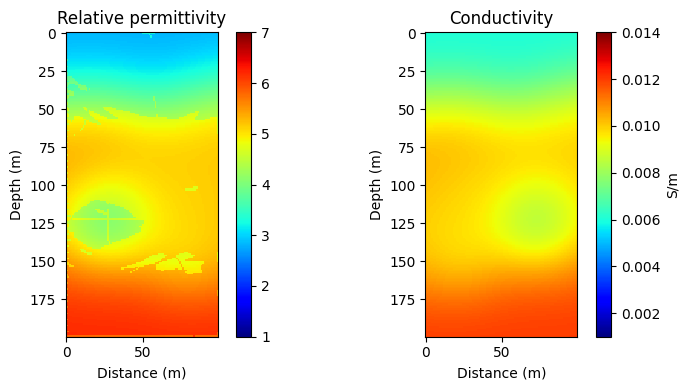

Epoch 1, Total Loss: 145477.50 (Data: 126961.28), Epoch Time: 0.66s, Total Time: 1.63s
Epoch 2, Total Loss: 147475.49 (Data: 121770.82), Epoch Time: 0.64s, Total Time: 2.27s
Epoch 3, Total Loss: 144757.59 (Data: 112563.95), Epoch Time: 0.65s, Total Time: 2.92s
Epoch 4, Total Loss: 141328.34 (Data: 104469.25), Epoch Time: 0.64s, Total Time: 3.57s
Epoch 5, Total Loss: 135626.48 (Data: 93748.70), Epoch Time: 0.65s, Total Time: 4.22s
Epoch 6, Total Loss: 134721.61 (Data: 88526.97), Epoch Time: 0.64s, Total Time: 4.85s
Epoch 7, Total Loss: 135330.93 (Data: 85733.61), Epoch Time: 0.65s, Total Time: 5.51s
Epoch 8, Total Loss: 125656.55 (Data: 73313.40), Epoch Time: 0.64s, Total Time: 6.15s
Epoch 9, Total Loss: 115862.00 (Data: 61008.94), Epoch Time: 0.66s, Total Time: 6.81s
Epoch 10, Total Loss: 122916.67 (Data: 65334.07), Epoch Time: 0.65s, Total Time: 7.46s
Epoch 11, Total Loss: 123640.48 (Data: 64179.61), Epoch Time: 0.65s, Total Time: 8.11s
Epoch 12, Total Loss: 123847.57 (Data: 62142.16)

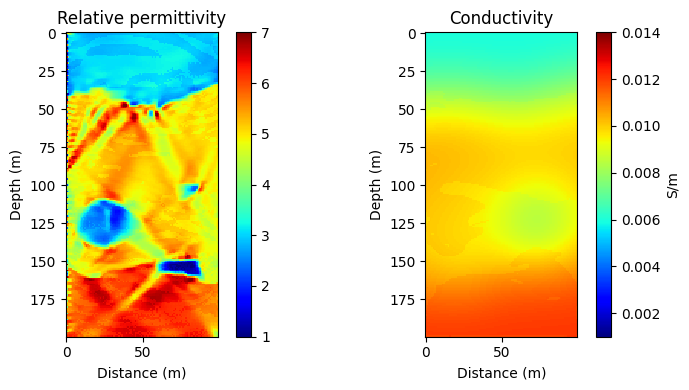

Epoch 51, Total Loss: 141204.47 (Data: 47977.37), Epoch Time: 0.62s, Total Time: 33.52s
Epoch 52, Total Loss: 137786.50 (Data: 45660.71), Epoch Time: 0.62s, Total Time: 34.14s
Epoch 53, Total Loss: 126608.78 (Data: 37393.34), Epoch Time: 0.62s, Total Time: 34.76s
Epoch 54, Total Loss: 119771.71 (Data: 32845.04), Epoch Time: 0.62s, Total Time: 35.38s
Epoch 55, Total Loss: 118718.82 (Data: 34603.31), Epoch Time: 0.63s, Total Time: 36.00s
Epoch 56, Total Loss: 109531.70 (Data: 28299.55), Epoch Time: 0.62s, Total Time: 36.62s
Epoch 57, Total Loss: 106693.30 (Data: 26948.12), Epoch Time: 0.61s, Total Time: 37.23s
Epoch 58, Total Loss: 105978.36 (Data: 27769.24), Epoch Time: 0.62s, Total Time: 37.86s
Epoch 59, Total Loss: 99605.77 (Data: 23231.52), Epoch Time: 0.61s, Total Time: 38.47s
Epoch 60, Total Loss: 99172.42 (Data: 23811.48), Epoch Time: 0.62s, Total Time: 39.08s
Epoch 61, Total Loss: 96577.32 (Data: 22775.26), Epoch Time: 0.63s, Total Time: 39.71s
Epoch 62, Total Loss: 90352.20 (Dat

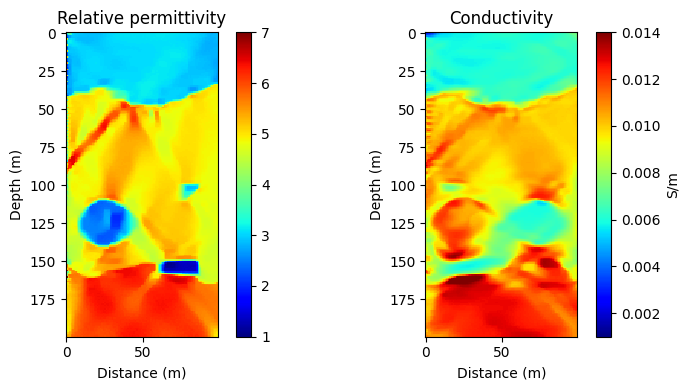

Epoch 101, Total Loss: 53802.77 (Data: 6323.51), Epoch Time: 0.63s, Total Time: 64.72s
Epoch 102, Total Loss: 53602.71 (Data: 6447.31), Epoch Time: 0.63s, Total Time: 65.36s
Epoch 103, Total Loss: 52966.13 (Data: 6345.54), Epoch Time: 0.64s, Total Time: 66.00s
Epoch 104, Total Loss: 51595.75 (Data: 5303.01), Epoch Time: 0.64s, Total Time: 66.64s
Epoch 105, Total Loss: 52108.89 (Data: 5793.36), Epoch Time: 0.63s, Total Time: 67.27s
Epoch 106, Total Loss: 52769.32 (Data: 6920.23), Epoch Time: 0.64s, Total Time: 67.91s
Epoch 107, Total Loss: 50833.68 (Data: 5481.64), Epoch Time: 0.63s, Total Time: 68.54s
Epoch 108, Total Loss: 52023.99 (Data: 6846.80), Epoch Time: 0.64s, Total Time: 69.18s
Epoch 109, Total Loss: 50233.90 (Data: 5468.19), Epoch Time: 0.65s, Total Time: 69.83s
Epoch 110, Total Loss: 51692.45 (Data: 7133.27), Epoch Time: 0.64s, Total Time: 70.47s
Epoch 111, Total Loss: 50192.24 (Data: 6061.58), Epoch Time: 0.64s, Total Time: 71.10s
Epoch 112, Total Loss: 50421.31 (Data: 6501

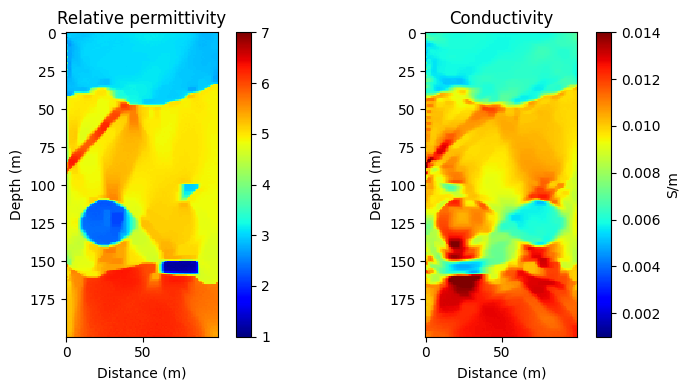

Epoch 151, Total Loss: 43176.23 (Data: 6571.61), Epoch Time: 0.62s, Total Time: 96.23s
Epoch 152, Total Loss: 43456.70 (Data: 6867.70), Epoch Time: 0.61s, Total Time: 96.84s
Epoch 153, Total Loss: 42320.10 (Data: 5954.22), Epoch Time: 0.61s, Total Time: 97.45s
Epoch 154, Total Loss: 42664.60 (Data: 6433.55), Epoch Time: 0.62s, Total Time: 98.07s
Epoch 155, Total Loss: 42466.83 (Data: 6341.62), Epoch Time: 0.63s, Total Time: 98.70s
Epoch 156, Total Loss: 42308.22 (Data: 6237.25), Epoch Time: 0.63s, Total Time: 99.33s
Epoch 157, Total Loss: 42502.83 (Data: 6576.62), Epoch Time: 0.64s, Total Time: 99.97s
Epoch 158, Total Loss: 42210.13 (Data: 6378.47), Epoch Time: 0.63s, Total Time: 100.60s
Epoch 159, Total Loss: 42600.67 (Data: 6889.88), Epoch Time: 0.64s, Total Time: 101.24s
Epoch 160, Total Loss: 42294.39 (Data: 6621.18), Epoch Time: 0.64s, Total Time: 101.88s
Epoch 161, Total Loss: 42237.73 (Data: 6707.08), Epoch Time: 0.64s, Total Time: 102.52s
Epoch 162, Total Loss: 41533.56 (Data: 

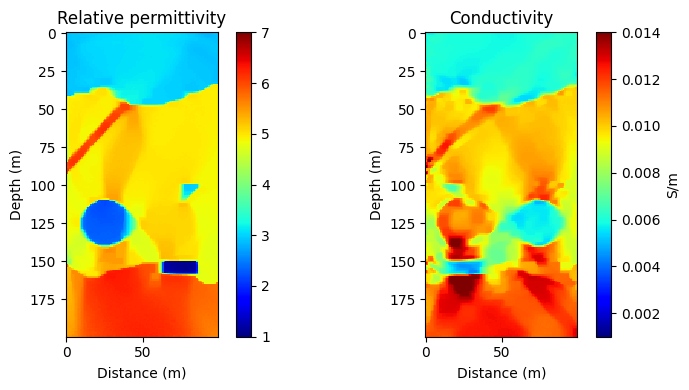

Epoch 201, Total Loss: 39731.05 (Data: 7172.51), Epoch Time: 0.64s, Total Time: 128.18s
Epoch 202, Total Loss: 38572.96 (Data: 6097.94), Epoch Time: 0.65s, Total Time: 128.83s
Epoch 203, Total Loss: 39348.40 (Data: 6859.39), Epoch Time: 0.63s, Total Time: 129.46s
Epoch 204, Total Loss: 39183.75 (Data: 6743.88), Epoch Time: 0.64s, Total Time: 130.10s
Epoch 205, Total Loss: 38019.07 (Data: 5628.46), Epoch Time: 0.64s, Total Time: 130.74s
Epoch 206, Total Loss: 37986.43 (Data: 5603.44), Epoch Time: 0.64s, Total Time: 131.38s
Epoch 207, Total Loss: 37977.03 (Data: 5697.36), Epoch Time: 0.63s, Total Time: 132.01s
Epoch 208, Total Loss: 37571.88 (Data: 5319.77), Epoch Time: 0.64s, Total Time: 132.66s
Epoch 209, Total Loss: 38200.62 (Data: 5974.21), Epoch Time: 0.63s, Total Time: 133.29s
Epoch 210, Total Loss: 37101.83 (Data: 4966.11), Epoch Time: 0.64s, Total Time: 133.93s
Epoch 211, Total Loss: 38527.67 (Data: 6340.62), Epoch Time: 0.64s, Total Time: 134.57s
Epoch 212, Total Loss: 37388.12 

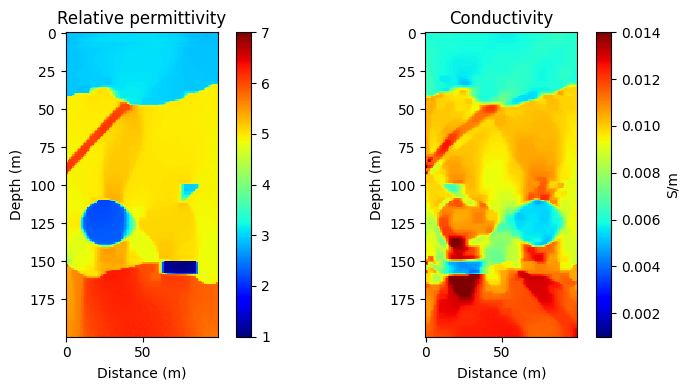

Epoch 251, Total Loss: 36877.16 (Data: 5948.78), Epoch Time: 0.61s, Total Time: 159.32s
Epoch 252, Total Loss: 36431.00 (Data: 5556.87), Epoch Time: 0.61s, Total Time: 159.93s
Epoch 253, Total Loss: 36469.26 (Data: 5593.42), Epoch Time: 0.64s, Total Time: 160.56s
Epoch 254, Total Loss: 35999.96 (Data: 5174.30), Epoch Time: 0.63s, Total Time: 161.19s
Epoch 255, Total Loss: 36366.04 (Data: 5558.78), Epoch Time: 0.63s, Total Time: 161.83s
Epoch 256, Total Loss: 36056.24 (Data: 5239.13), Epoch Time: 0.64s, Total Time: 162.47s
Epoch 257, Total Loss: 36392.23 (Data: 5630.82), Epoch Time: 0.63s, Total Time: 163.10s
Epoch 258, Total Loss: 35330.39 (Data: 4628.03), Epoch Time: 0.64s, Total Time: 163.74s
Epoch 259, Total Loss: 37158.69 (Data: 6474.50), Epoch Time: 0.64s, Total Time: 164.38s
Epoch 260, Total Loss: 36815.04 (Data: 6165.89), Epoch Time: 0.63s, Total Time: 165.02s
Epoch 261, Total Loss: 36191.49 (Data: 5487.59), Epoch Time: 0.64s, Total Time: 165.65s
Epoch 262, Total Loss: 36080.49 

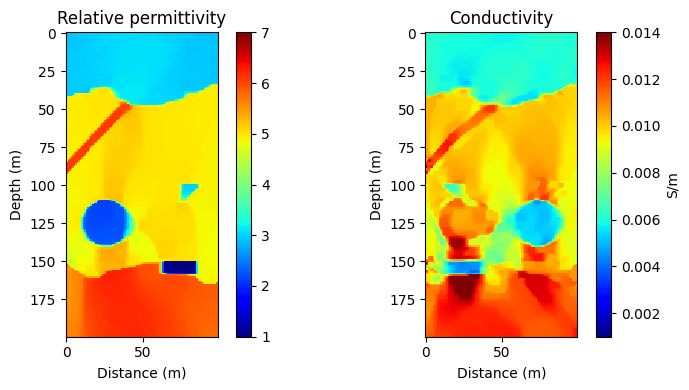

In [23]:

tv_ratio = 0.1 

for epoch in range(n_epochs):
    if epoch < phase1_epochs:
        current_optimizer = optimiser_phase1
        se.requires_grad = False 
        er.requires_grad = True  
    else:
        current_optimizer = optimiser_phase2
        se.requires_grad = True    
        er.requires_grad = True   
    
    epoch_start = time.time()
    
    current_optimizer.zero_grad()

    r = DeepGPR.compute(
        device=device, dx=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_location=source_location, 
        receiver_location=receiver_location, 
        er=er, se=se,model_gradient_sampling_interval=5
    )[-1]
  
    loss_data = loss_fnl1(r, r_obs) * 1e7
    loss_data.backward()

    if er.requires_grad:
        grad_data_er = er.grad.clone() 
        norm_data_er = torch.norm(grad_data_er) + 1e-8 
        
    if se.requires_grad:
        grad_data_se = se.grad.clone() 
        norm_data_se = torch.norm(grad_data_se) + 1e-8

    current_optimizer.zero_grad()  
    
    loss_tv = tv_criterion(er, se)
    loss_tv.backward()  

    if er.requires_grad:
        norm_tv_er = torch.norm(er.grad) + 1e-8
        weight_tv_er = (norm_data_er / norm_tv_er) * tv_ratio
        er.grad = grad_data_er + er.grad * weight_tv_er

    if se.requires_grad:
        norm_tv_se = torch.norm(se.grad) + 1e-8
        weight_tv_se = (norm_data_se / norm_tv_se) * tv_ratio
        se.grad = grad_data_se + se.grad * weight_tv_se

    current_optimizer.step()
    total_loss = loss_data.item() + loss_tv.item()
    losses.append(total_loss) 
    
    epoch_time = time.time() - epoch_start  
    total_time = time.time() - start_time  
    
    with torch.no_grad():
        se.data.clamp_(min=0)
        er.data.clamp_(min=1)
        
    print(f"Epoch {epoch}, Total Loss: {total_loss:.2f} (Data: {loss_data.item():.2f}), Epoch Time: {epoch_time:.2f}s, Total Time: {total_time:.2f}s")
    
    if epoch % 50 == 0:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
        im1 = axes[0].imshow(er.detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=7,vmin=1)
        cbar1 = plt.colorbar(im1, ax=axes[0])
        axes[0].set_title('Relative permittivity')
        axes[0].set_xlabel('Distance (m)')
        axes[0].set_ylabel('Depth (m)')

        im2 = axes[1].imshow(se.detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=0.014,vmin=0.001)
        cbar2 = plt.colorbar(im2, ax=axes[1])
        cbar2.set_label('S/m')
        axes[1].set_title('Conductivity')
        axes[1].set_xlabel('Distance (m)')
        axes[1].set_ylabel('Depth (m)')

        plt.tight_layout()
        plt.show()